In [29]:
import tensorflow as tf

In [30]:
 mnist=tf.keras.datasets.mnist



In [31]:
mnist

<module 'keras.datasets.mnist' from 'C:\\Users\\Slim1\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\keras\\datasets\\mnist\\__init__.py'>

In [32]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [33]:
x_train.shape

(60000, 28, 28)

In [34]:
y_train.shape

(60000,)

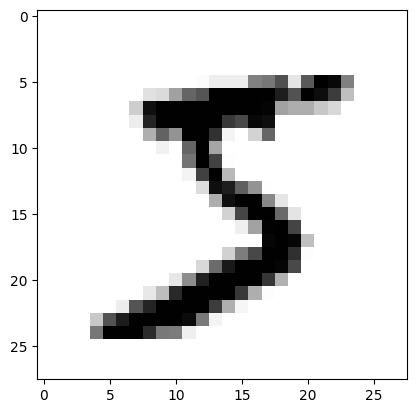

In [35]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0],cmap=plt.cm.binary)


In [37]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [39]:
x_train=tf.keras.utils.normalize(x_train)
x_test=tf.keras.utils.normalize(x_test)


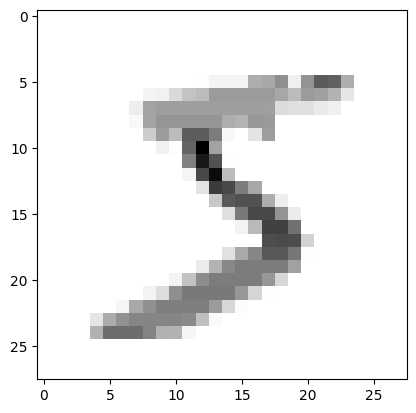

In [47]:
plt.imshow(x_train[0],cmap=plt.cm.binary)

In [49]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [55]:
import numpy as np
x_trainr=np.array(x_train).reshape(-1,28,28,1)
x_testr=np.array(x_test).reshape(-1,28,28,1)



In [56]:
x_trainr.shape

(60000, 28, 28, 1)

In [58]:
x_testr.shape

(10000, 28, 28, 1)

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation, Flatten , Conv2D,  MaxPooling2D


In [72]:
model=Sequential()

In [78]:
model = Sequential()

model.add(Conv2D(64, (3,3), padding="same", input_shape=(28,28,1)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="same"))
model.add(Activation("relu"))

# no more pooling here, go to Flatten
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

model.add(Dense(32))
model.add(Activation("relu"))

model.add(Dense(10))
model.add(Activation("softmax"))


In [80]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_15 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_16 (Activation)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_17 (Activation)           │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 277,674 (1.06 MB)

 Trainable params: 277,674 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_trainr, y_train, epochs=10,validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.9436 - loss: 0.1791 - val_accuracy: 0.9837 - val_loss: 0.0502
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9830 - loss: 0.0540 - val_accuracy: 0.9838 - val_loss: 0.0536
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9878 - loss: 0.0386 - val_accuracy: 0.9875 - val_loss: 0.0427
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9913 - loss: 0.0283 - val_accuracy: 0.9890 - val_loss: 0.0350
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.9910 - val_loss: 0.0307
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 77s 45ms/step - accuracy: 0.9944 - loss: 0.0176 - val_accuracy: 0.9875 - val_loss: 0.0445
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9953 - loss: 0.0157 - val_accuracy: 0.9920 - val_loss: 0.0383
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9954 -

In [94]:
test_loss, test_acc = model.evaluate(x_testr, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9902 - loss: 0.0404
Test Accuracy: 99.02%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


7

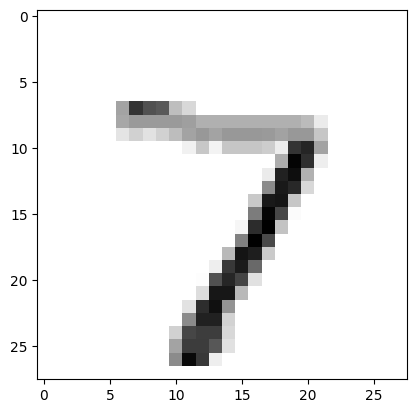

In [113]:
index = x_testr[0]
sample_image = index.reshape(1,28,28,1)
predicted_class = np.argmax(model.predict(sample_image))
plt.imshow(index.reshape(28,28), cmap=plt.cm.binary)

predicted_class


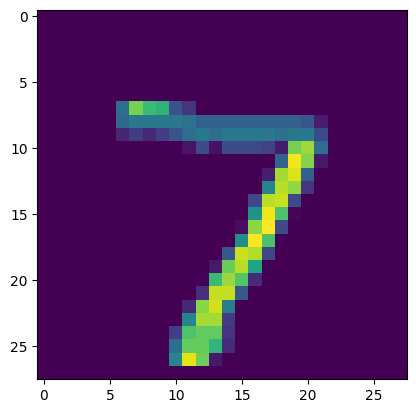

In [107]:
 plt.imshow(x_testr[0])

In [111]:
predicted_class

7